In [2]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================================
# STEP 2: LOAD DATASET
# ============================================================

file_path = "creditcard.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# ============================================================
# STEP 3: BASIC DATA UNDERSTANDING
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

DATASET INFORMATION

Shape:
(284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Last 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# ============================================================
# STEP 4: CHECK MISSING VALUES
# ============================================================

print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values:
0


In [6]:
# ============================================================
# STEP 5: CHECK DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [7]:
# ============================================================
# STEP 6: STATISTICAL SUMMARY
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [9]:
# ============================================================
# STEP 7: TARGET DISTRIBUTION
# ============================================================

class_counts = df["Class"].value_counts()

print("Transaction Class Distribution:")
print(class_counts)

print("\nClass Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Transaction Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


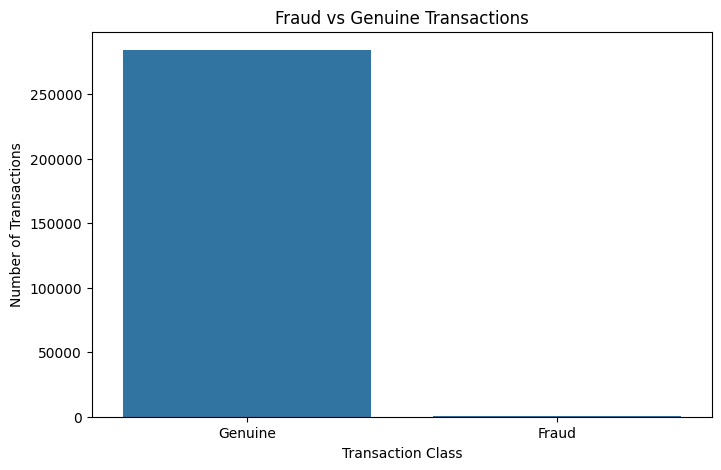

In [10]:
# ============================================================
# STEP 8: FRAUD VS NON-FRAUD VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

In [11]:
# ============================================================
# STEP 9: FRAUD PERCENTAGE
# ============================================================

fraud_count = df["Class"].sum()
total_transactions = len(df)

fraud_percentage = (fraud_count / total_transactions) * 100

print("Total Transactions:", total_transactions)
print("Fraudulent Transactions:", fraud_count)
print(f"Fraud Percentage: {fraud_percentage:.4f}%")

Total Transactions: 284807
Fraudulent Transactions: 492
Fraud Percentage: 0.1727%


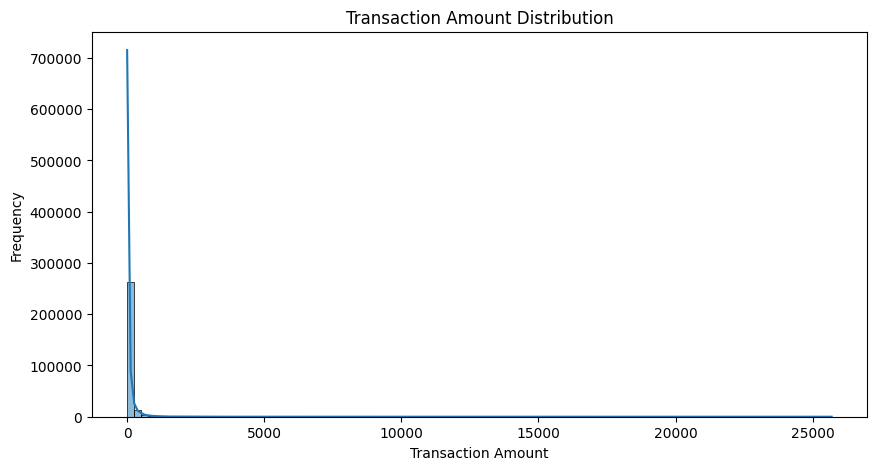

In [12]:
# ============================================================
# STEP 10: TRANSACTION AMOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Amount"],
    bins=100,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

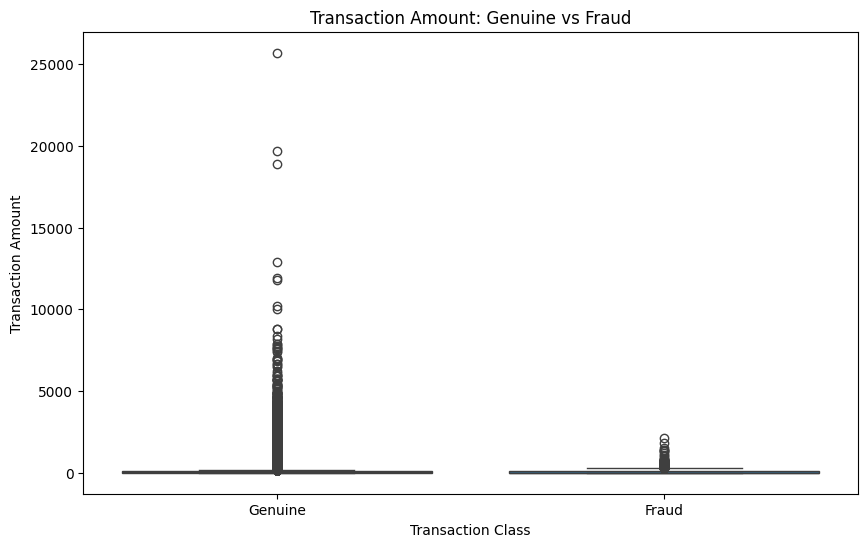

In [13]:
# ============================================================
# STEP 11: TRANSACTION AMOUNT BY CLASS
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount: Genuine vs Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Genuine", "Fraud"]
)

plt.show()

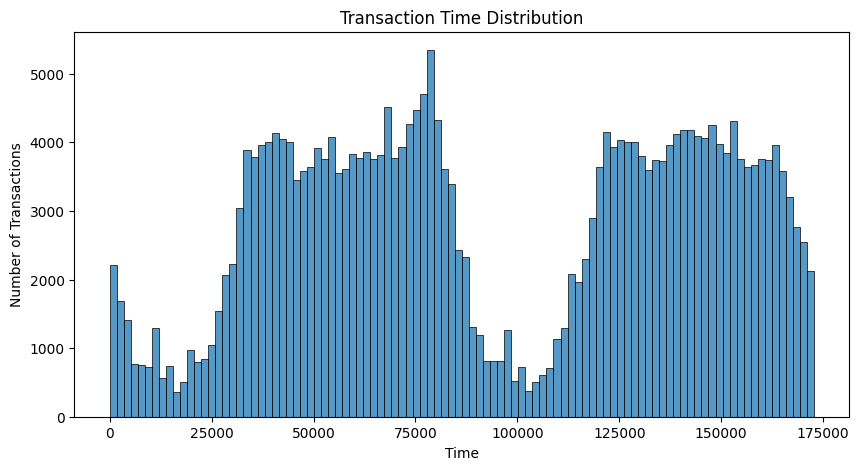

In [15]:
# ============================================================
# STEP 12: TRANSACTION TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

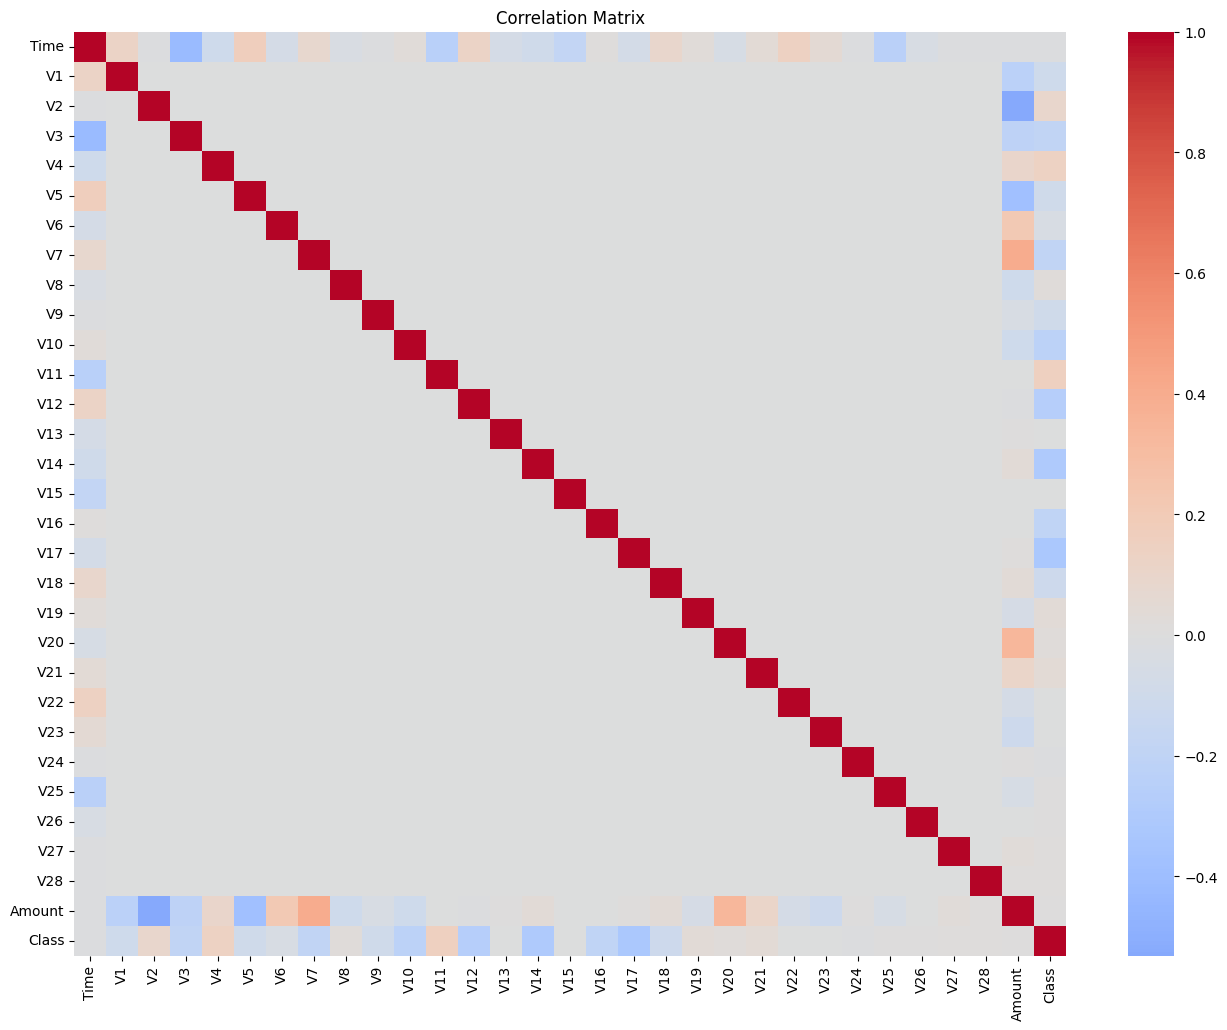

In [16]:
# ============================================================
# STEP 13: CORRELATION ANALYSIS
# ============================================================

plt.figure(figsize=(16, 12))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [17]:
# ============================================================
# STEP 14: FRAUD TRANSACTION STATISTICS
# ============================================================

fraud_transactions = df[df["Class"] == 1]
genuine_transactions = df[df["Class"] == 0]

print("Fraud Transactions:")
display(fraud_transactions.describe().T)

print("\nGenuine Transactions:")
display(genuine_transactions.describe().T)

Fraud Transactions:


,count,mean,std,min,25%,50%,75%,max
Time,492.0,80746.806911,47835.365138,406.000000,41241.500000,75568.500000,128483.000000,170348.000000
V1,492.0,-4.771948,6.783687,-30.552380,-6.036063,-2.342497,-0.419200,2.132386
V2,492.0,3.623778,4.291216,-8.402154,1.188226,2.717869,4.971257,22.057729
V3,492.0,-7.033281,7.110937,-31.103685,-8.643489,-5.075257,-2.276185,2.250210
V4,492.0,4.542029,2.873318,-1.313275,2.373050,4.177147,6.348729,12.114672
V5,492.0,-3.151225,5.372468,-22.105532,-4.792835,-1.522962,0.214562,11.095089
V6,492.0,-1.397737,1.858124,-6.406267,-2.501511,-1.424616,-0.413216,6.474115
V7,492.0,-5.568731,7.206773,-43.557242,-7.965295,-3.034402,-0.945954,5.802537
V8,492.0,0.570636,6.797831,-41.044261,-0.195336,0.621508,1.764879,20.007208
V9,492.0,-2.581123,2.500896,-13.434066,-3.872383,-2.208768,-0.787850,3.353525



Genuine Transactions:


,count,mean,std,min,25%,50%,75%,max
Time,284315.0,94838.202258,47484.015786,0.000000,54230.000000,84711.000000,139333.000000,172792.000000
V1,284315.0,0.008258,1.929814,-56.407510,-0.917544,0.020023,1.316218,2.454930
V2,284315.0,-0.006271,1.636146,-72.715728,-0.599473,0.064070,0.800446,18.902453
V3,284315.0,0.012171,1.459429,-48.325589,-0.884541,0.182158,1.028372,9.382558
V4,284315.0,-0.007860,1.399333,-5.683171,-0.850077,-0.022405,0.737624,16.875344
V5,284315.0,0.005453,1.356952,-113.743307,-0.689398,-0.053457,0.612181,34.801666
V6,284315.0,0.002419,1.329913,-26.160506,-0.766847,-0.273123,0.399619,73.301626
V7,284315.0,0.009637,1.178812,-31.764946,-0.551442,0.041138,0.571019,120.589494
V8,284315.0,-0.000987,1.161283,-73.216718,-0.208633,0.022041,0.326200,18.709255
V9,284315.0,0.004467,1.089372,-6.290730,-0.640412,-0.049964,0.598230,15.594995


In [18]:
# ============================================================
# STEP 15: COMPARE TRANSACTION AMOUNTS
# ============================================================

comparison = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

comparison.index = ["Genuine", "Fraud"]

display(comparison)

,count,mean,median,std,min,max
Genuine,284315,88.291022,22.00,250.105092,0.0,25691.16
Fraud,492,122.211321,9.25,256.683288,0.0,2125.87


In [19]:
# ============================================================
# STEP 16: AVERAGE TRANSACTION AMOUNT
# ============================================================

average_amount = df.groupby("Class")["Amount"].mean()

print(average_amount)

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64


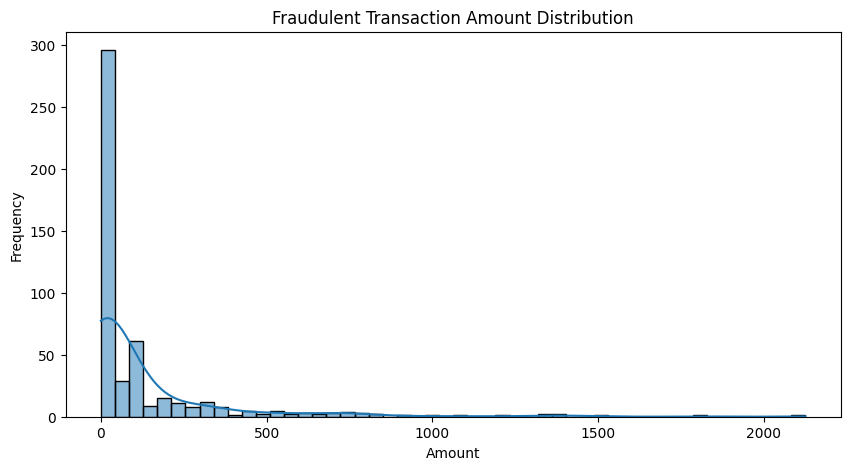

In [20]:
# ============================================================
# STEP 17: FRAUD AMOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    fraud_transactions["Amount"],
    bins=50,
    kde=True
)

plt.title("Fraudulent Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [21]:
# ============================================================
# STEP 18: FEATURE MEAN COMPARISON
# ============================================================

feature_means = df.groupby("Class").mean().T

display(feature_means.head(15))

Class,0,1
Time,94838.202258,80746.806911
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123


In [22]:
# ============================================================
# STEP 19: FEATURES MOST CORRELATED WITH FRAUD
# ============================================================

target_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

display(target_correlation.head(15))

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
Name: Class, dtype: float64

In [23]:
# ============================================================
# STEP 19: FEATURES MOST CORRELATED WITH FRAUD
# ============================================================

target_correlation = (
    df.corr()["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

display(target_correlation.head(15))

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V2     0.091289
V6    -0.043643
Name: Class, dtype: float64

In [24]:
# ============================================================
# STEP 21: FRAUD RATE BY TRANSACTION AMOUNT
# ============================================================

df["AmountGroup"] = pd.qcut(
    df["Amount"],
    q=10,
    duplicates="drop"
)

amount_fraud_rate = (
    df.groupby("AmountGroup", observed=True)["Class"]
    .mean()
    * 100
)

display(amount_fraud_rate)

AmountGroup
(-0.001, 1.0]        0.593598
(1.0, 3.57]          0.101991
(3.57, 8.91]         0.126055
(8.91, 13.0]         0.045767
(13.0, 22.0]         0.048757
(22.0, 37.0]         0.059912
(37.0, 59.8]         0.084608
(59.8, 100.0]        0.172921
(100.0, 203.0]       0.160428
(203.0, 25691.16]    0.298686
Name: Class, dtype: float64

In [25]:
# ============================================================
# STEP 22: FRAUD RATE BY TIME GROUP
# ============================================================

df["TimeGroup"] = pd.qcut(
    df["Time"],
    q=10,
    duplicates="drop"
)

time_fraud_rate = (
    df.groupby("TimeGroup", observed=True)["Class"]
    .mean()
    * 100
)

display(time_fraud_rate)

TimeGroup
(-0.001, 35027.0]       0.326522
(35027.0, 47694.2]      0.224719
(47694.2, 60776.0]      0.165011
(60776.0, 73261.4]      0.129925
(73261.4, 84692.0]      0.098311
(84692.0, 120396.0]     0.319478
(120396.0, 132929.0]    0.084270
(132929.0, 145247.8]    0.115883
(145247.8, 157640.4]    0.186089
(157640.4, 172792.0]    0.077244
Name: Class, dtype: float64

In [26]:
# ============================================================
# STEP 23: DIAGNOSTIC SUMMARY
# ============================================================

print("=" * 70)
print("DIAGNOSTIC ANALYTICS SUMMARY")
print("=" * 70)

print("\nTotal Transactions:", len(df))
print("Fraud Transactions:", df["Class"].sum())
print("Genuine Transactions:", (df["Class"] == 0).sum())

print(
    f"\nFraud Rate: "
    f"{df['Class'].mean() * 100:.4f}%"
)

print(
    f"\nAverage Genuine Amount: "
    f"{df[df['Class'] == 0]['Amount'].mean():.2f}"
)

print(
    f"Average Fraud Amount: "
    f"{df[df['Class'] == 1]['Amount'].mean():.2f}"
)

DIAGNOSTIC ANALYTICS SUMMARY

Total Transactions: 284807
Fraud Transactions: 492
Genuine Transactions: 284315

Fraud Rate: 0.1727%

Average Genuine Amount: 88.29
Average Fraud Amount: 122.21


In [27]:
# ============================================================
# STEP 24: PREPARE MACHINE LEARNING DATA
# ============================================================

# Remove helper columns
df_model = df.drop(
    columns=["AmountGroup", "TimeGroup"],
    errors="ignore"
).copy()

X = df_model.drop("Class", axis=1)
y = df_model["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


In [28]:
# ============================================================
# STEP 25: TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 227845
Testing samples: 56962

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [29]:
# ============================================================
# STEP 26: STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [30]:
# ============================================================
# STEP 27: HANDLE CLASS IMBALANCE USING SMOTE
# ============================================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [31]:
# ============================================================
# STEP 28: LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression model trained.")

Logistic Regression model trained.


In [32]:
# ============================================================
# STEP 29: LOGISTIC REGRESSION PREDICTION
# ============================================================

y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [33]:
# ============================================================
# STEP 30: LOGISTIC REGRESSION EVALUATION
# ============================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)
lr_pr_auc = average_precision_score(y_test, y_prob_lr)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")
print(f"PR-AUC:    {lr_pr_auc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy:  0.9741
Precision: 0.0578
Recall:    0.9184
F1 Score:  0.1088
ROC-AUC:   0.9708
PR-AUC:    0.7245


In [34]:
# ============================================================
# STEP 30: LOGISTIC REGRESSION EVALUATION
# ============================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)
lr_pr_auc = average_precision_score(y_test, y_prob_lr)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")
print(f"PR-AUC:    {lr_pr_auc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy:  0.9741
Precision: 0.0578
Recall:    0.9184
F1 Score:  0.1088
ROC-AUC:   0.9708
PR-AUC:    0.7245


In [36]:
# ============================================================
# STEP 32: RANDOM FOREST PREDICTION
# ============================================================

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated.")

NameError: name 'rf_model' is not defined

In [37]:
# ============================================================
# STEP 33: RANDOM FOREST EVALUATION
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

NameError: name 'y_pred_rf' is not defined